In [5]:
# stb_image.h allows reading png and jpg images
# stb_image_write.h allows saving the output image

!wget https://raw.githubusercontent.com/nothings/stb/master/stb_image.h
!wget https://raw.githubusercontent.com/nothings/stb/master/stb_image_write.h

--2026-05-10 17:45:09--  https://raw.githubusercontent.com/nothings/stb/master/stb_image.h
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 283010 (276K) [text/plain]
Saving to: ‘stb_image.h.1’

stb_image.h.1       100%[===================>] 276.38K  --.-KB/s    in 0.07s   

2026-05-10 17:45:09 (4.09 MB/s) - ‘stb_image.h.1’ saved [283010/283010]

--2026-05-10 17:45:09--  https://raw.githubusercontent.com/nothings/stb/master/stb_image_write.h
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 71221 (70K) [text/plain]
Saving to: ‘stb_im

In [6]:
%%writefile pure_kmeans_1channel.cpp
#define STB_IMAGE_IMPLEMENTATION
#include "stb_image.h"
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "stb_image_write.h"

#include <algorithm>
#include <chrono>
#include <cstdlib>
#include <ctime>
#include <iostream>
#include <vector>

using namespace std;

// Structure to store the single grayscale intensity of our cluster centers
struct Centroid {
    double intensity;
};

double getSquaredDistance(unsigned char* pixel, Centroid c) {
    double diff = pixel[0] - c.intensity;
    return diff * diff;
}

int main(int argc, char** argv) {
    // 1. INPUT VALIDATION
    if (argc < 3) {
        cout << "Usage: ./pure_kmeans_1channel <image_path> <K>" << endl;
        return -1;
    }

    const char* img_path = argv[1];
    int K = atoi(argv[2]);
    int max_iters = 100;

    // 2. LOAD IMAGE
    int width, height, channels;
    // stbi_load returns a 1D array of bytes. We force 1 channel (grayscale).
    unsigned char* img_data = stbi_load(img_path, &width, &height, &channels, 1);
    if (!img_data) {
        cout << "Error: Could not read the image." << endl;
        return -1;
    }

    int total_pixels = width * height;
    if (K <= 0 || K > total_pixels) {
        cout << "Error: K must be between 1 and the number of pixels in the image." << endl;
        stbi_image_free(img_data);
        return -1;
    }

    // 3. INITIALIZATION
    srand(time(0));
    vector<Centroid> centroids(K);
    vector<int> labels(total_pixels, 0);

    // Pick K random pixels from the image to act as starting centroids
    for (int i = 0; i < K; i++) {
        int random_idx = rand() % total_pixels;
        centroids[i].intensity = img_data[random_idx];
    }

    vector<double> sum_intensity(K);
    vector<int> counts(K);

    bool changed = true;
    int iter = 0;

    cout << "Starting optimized 1-channel K-Means clustering..." << endl;

    auto start_time = chrono::high_resolution_clock::now();

    // 4. MAIN ALGORITHM LOOP
    while (changed && iter < max_iters) {
        changed = false;

        // Reset the accumulators to zero for the new iteration
        fill(sum_intensity.begin(), sum_intensity.end(), 0.0);
        fill(counts.begin(), counts.end(), 0);

        // Step A: Assign every pixel to the nearest centroid
        for (int p = 0; p < total_pixels; p++) {
            unsigned char* pixel = &img_data[p];

            double min_dist = 1e18;
            int best_cluster = 0;

            for (int c = 0; c < K; c++) {
                double dist = getSquaredDistance(pixel, centroids[c]);
                if (dist < min_dist) {
                    min_dist = dist;
                    best_cluster = c;
                }
            }

            if (labels[p] != best_cluster) {
                changed = true;
                labels[p] = best_cluster;
            }

            // Add pixel intensity to the newly assigned cluster's running total
            sum_intensity[best_cluster] += pixel[0];
            counts[best_cluster]++;
        }

        // Step B: Calculate the new centroids (averages)
        for (int c = 0; c < K; c++) {
            if (counts[c] > 0) {
                centroids[c].intensity = sum_intensity[c] / counts[c];
            }
        }
        iter++;
    }

    auto end_time = chrono::high_resolution_clock::now();
    chrono::duration<double, milli> elapsed_ms = end_time - start_time;

    // 5. RECONSTRUCT IMAGE
    // Allocate a new array for the final segmented image (1 byte per pixel)
    unsigned char* out_data = new unsigned char[total_pixels];

    for (int p = 0; p < total_pixels; p++) {
        int cluster_idx = labels[p];
        out_data[p] = static_cast<unsigned char>(centroids[cluster_idx].intensity);
    }

    // Write the result to a PNG file (lossless is better for medical imaging)
    stbi_write_png("pure_segmented_output.png", width, height, 1, out_data, width);

    cout << "Segmentation complete in " << iter << " iterations." << endl;
    cout << "Computation time: " << elapsed_ms.count() << " ms" << endl;

    // 6. CLEANUP MEMORY
    stbi_image_free(img_data);
    delete[] out_data;

    return 0;
}

Overwriting pure_kmeans_1channel.cpp


In [7]:
# Compile the grayscale implementation for Colab
!g++ -O2 -std=c++17 pure_kmeans_1channel.cpp -o pure_kmeans_exec

# Run the executable with the Google Drive image path
!./pure_kmeans_exec "/content/drive/MyDrive/(PUBLIC) Parallel Project/Sample_Images/Sample_6_Slice_97.png" 3

Starting optimized 1-channel K-Means clustering...
Segmentation complete in 14 iterations.
Computation time: 10.15 ms


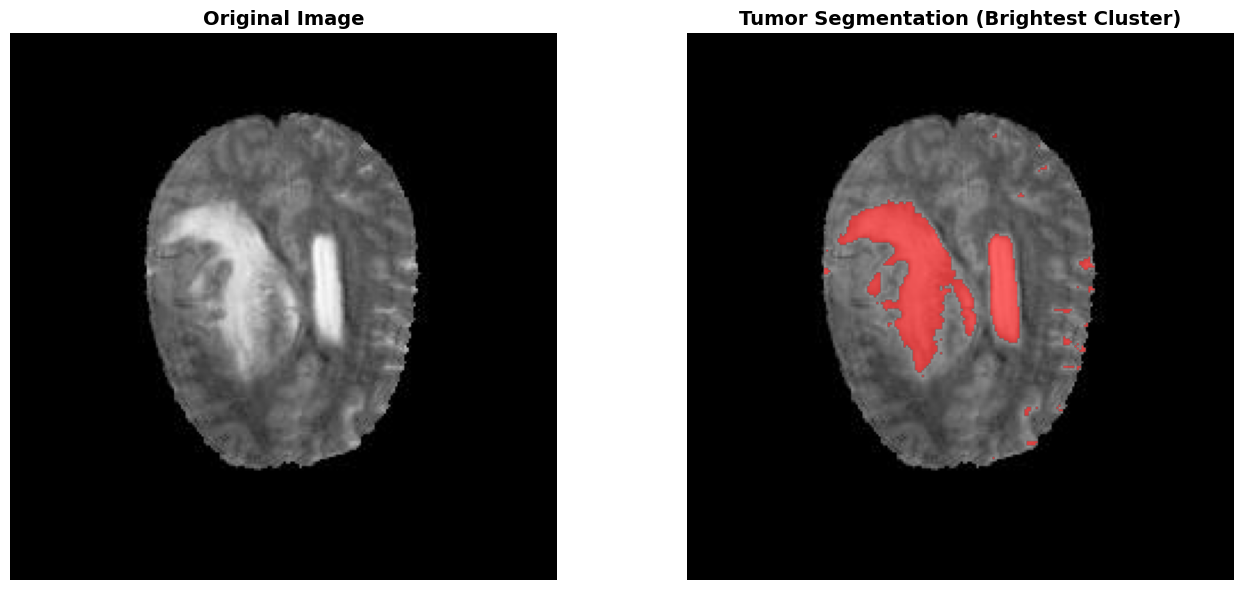

✓ Segmentation Complete: Tumor cluster identified (centroid intensity: 192.0)


In [10]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from matplotlib.colors import ListedColormap
import os

input_path = "/content/drive/MyDrive/(PUBLIC) Parallel Project/Sample_Images/Sample_6_Slice_97.png"
output_path = "pure_segmented_output.png"

if os.path.exists(output_path) and os.path.exists(input_path):
    original = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
    segmented = cv2.imread(output_path, cv2.IMREAD_GRAYSCALE)

    if original is not None and segmented is not None:
        # Get unique centroid values from the segmented output
        unique_centroids = np.unique(segmented)

        # Find the cluster with the highest brightness (tumor)
        brightest_centroid = np.max(unique_centroids)
        tumor_mask = np.ma.masked_where(segmented != brightest_centroid, segmented)

        # Create a red colormap for the tumor
        red_cmap = ListedColormap(['red'])

        # Create side-by-side visualization with overlay
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Left: Original image only
        axes[0].imshow(original, cmap='gray')
        axes[0].set_title("Original Image", fontsize=14, fontweight='bold')
        axes[0].axis('off')

        # Right: Original image + red tumor overlay
        axes[1].imshow(original, cmap='gray')
        axes[1].imshow(tumor_mask, cmap=red_cmap, alpha=0.6)
        axes[1].set_title(f"Tumor Segmentation (Brightest Cluster)", fontsize=14, fontweight='bold')
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

        print(f"✓ Segmentation Complete: Tumor cluster identified (centroid intensity: {brightest_centroid:.1f})")
    else:
        print("Error: Could not load the input or output image.")
else:
    print("Error: Output image not found. Make sure the compile/run cell completed successfully.")